# 📊 Análisis Complementario (Supplemental)

## 📑 Índice

0. [Introducción](#introduccion)  
1. [Imports](#imports)  
2. [Carga de datos](#carga-datos)  
3. [Exploración inicial](#exploracion-inicial)  
4. [Análisis de los datos](#analisis-datos)  
5. [Conclusiones](#conclusiones)  

<a id="introduccion"></a>
## Introducción 📑

Este documento recoge un **análisis complementario (supplemental)** al estudio principal del proyecto, con el objetivo de profundizar en variables y relaciones que aportan contexto adicional a la interpretación de los resultados.

A diferencia del análisis principal, aquí exportamos otros segmentos de forma más específica, cruces adicionales de variables y patrones secundarios.

Este análisis no forma parte del flujo principal del modelo, pero aporta **insights relevantes** para:
- Detectar oportunidades de mejora en las campañas
- Entender mejor determinados segmentos de clientes
- Validar hipótesis generadas durante el análisis exploratorio

[⬆ Volver al índice](#indice)

<a id="imports"></a>
## Imports 📦

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from functions import *
from matplotlib import rcParams

# Expresiones regulares
import re
from fuzzywuzzy import process

c:\Users\migue\anaconda3\envs\TFM\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


[⬆ Volver al índice](#indice)

<a id="carga-datos"></a>
## Carga de datos 📂

In [2]:
df = pd.read_csv('../Data/bank-additional_bank-additional-full.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="exploracion-inicial"></a>
## Exploración de datos inicial 🔎

In [3]:
check_df(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 41,188 filas y 21 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



##########################################################################################

Estadísticas descriptivas (categóricas):


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548



##########################################################################################



(       age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 0       56       261         1    999         0           1.1          93.994   
 1       57       149         1    999         0           1.1          93.994   
 2       37       226         1    999         0           1.1          93.994   
 3       40       151         1    999         0           1.1          93.994   
 4       56       307         1    999         0           1.1          93.994   
 ...    ...       ...       ...    ...       ...           ...             ...   
 41183   73       334         1    999         0          -1.1          94.767   
 41184   46       383         1    999         0          -1.1          94.767   
 41185   56       189         2    999         0          -1.1          94.767   
 41186   44       442         1    999         0          -1.1          94.767   
 41187   74       239         3    999         1          -1.1          94.767   
 
        cons.c

In [4]:
identificacion_valores_problem(df)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
age               0.0
campaign          0.0
nr.employed       0.0
euribor3m         0.0
cons.conf.idx     0.0
cons.price.idx    0.0
emp.var.rate      0.0
poutcome          0.0
previous          0.0
pdays             0.0
duration          0.0
job               0.0
day_of_week       0.0
month             0.0
contact           0.0
loan              0.0
housing           0.0
default           0.0
education         0.0
marital           0.0
y                 0.0
dtype: float64
###################################################################################
3.1.2. Número de DUPLICADOS totales: 12
###################################################################################
3.1.3. Columnas numéricas con OUTLIERS
Número de outliers en la columna "age": 469
Número de outliers en la columna "duration": 2963
Número de outliers e

In [5]:
print('la información duplicada que tenemos:')
df[df.duplicated()]

la información duplicada que tenemos:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [6]:
df.drop_duplicates(df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="analisis-datos"></a>
## Análisis de los datos 🧠

### Tasa de Conversión Total

La tasa de conversión total de la campaña es **11%.**

In [7]:
(df.query('y == "yes"')['y'].count() / df['y'].count()).round(2)

np.float64(0.11)

### Modo de Contacto

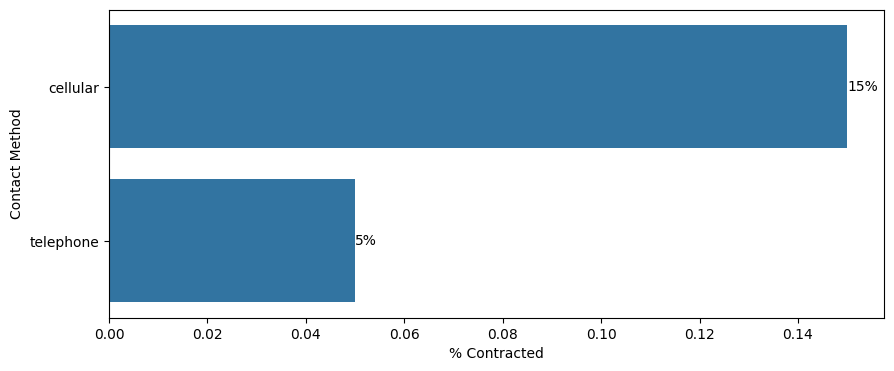

In [8]:

fig, ax = plt.subplots(figsize=(10, 4))

ax = sns.barplot(
    df.groupby(['contact'])['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x = 'proportion',
    y = 'contact'
)

ax.set(xlabel='% Contracted', ylabel='Contact Method')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

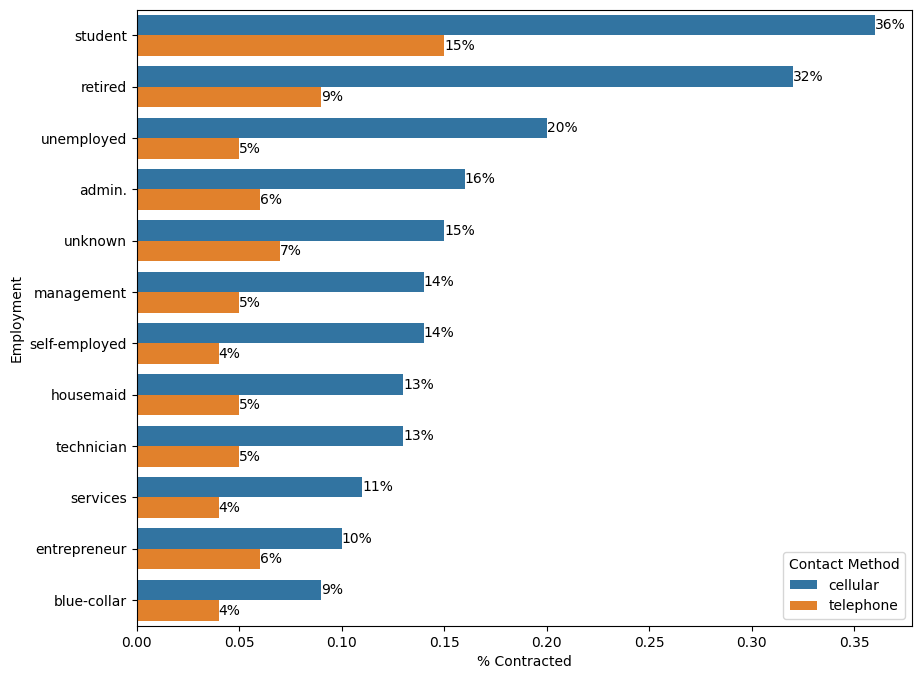

In [9]:
ax = plt.subplots(figsize=(10, 8))

ax = sns.barplot(
    df.groupby(['job','contact'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['job','contact'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job',
    hue = 'contact'
)

ax.set(xlabel='% Contracted', ylabel='Employment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.legend(title='Contact Method')


plt.show()

<a id="duracion"></a>
### Duración de llamadas

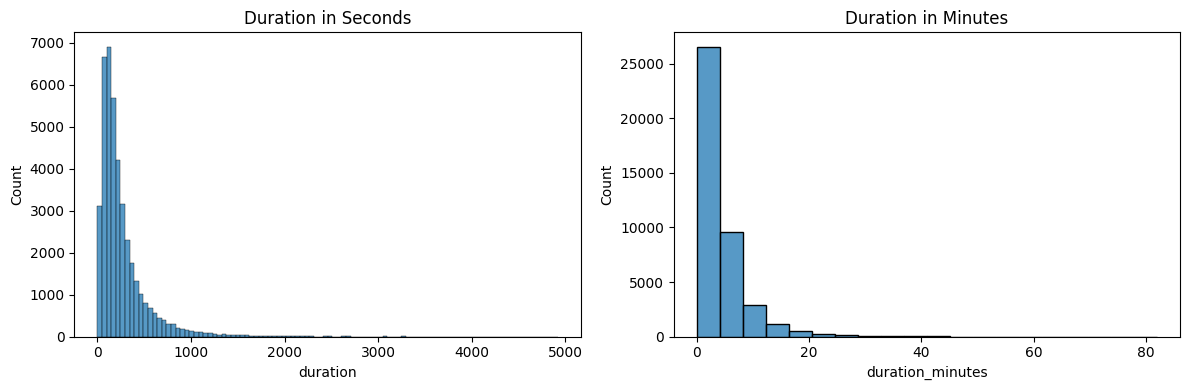

In [10]:
df['duration_minutes'] = df['duration'] / 60

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df,
    x="duration",
    bins=100,
    ax=ax1
)

sns.histplot(
    data=df,
    x="duration_minutes",
    bins=20,
    ax=ax2
)

ax1.set_title('Duration in Seconds')
ax2.set_title('Duration in Minutes')

plt.tight_layout()
plt.show()

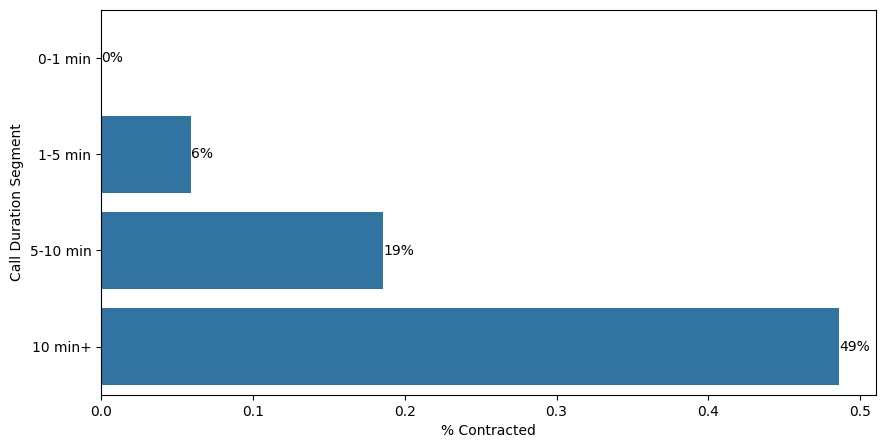

In [11]:
bins = [0, 60, 300, 600, np.inf]
names = ['0-1 min', '1-5 min', '5-10 min', '10 min+']

df['duration_segment'] = pd.cut(df['duration'], bins, labels=names)

fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.barplot(
    df.groupby('duration_segment', observed= True)['y'].value_counts(normalize= True).reset_index().pivot(index= 'duration_segment', columns = 'y', values = 'proportion'),
    x = 'yes',
    y = 'duration_segment'
)

ax.set(xlabel='% Contracted', ylabel='Call Duration Segment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

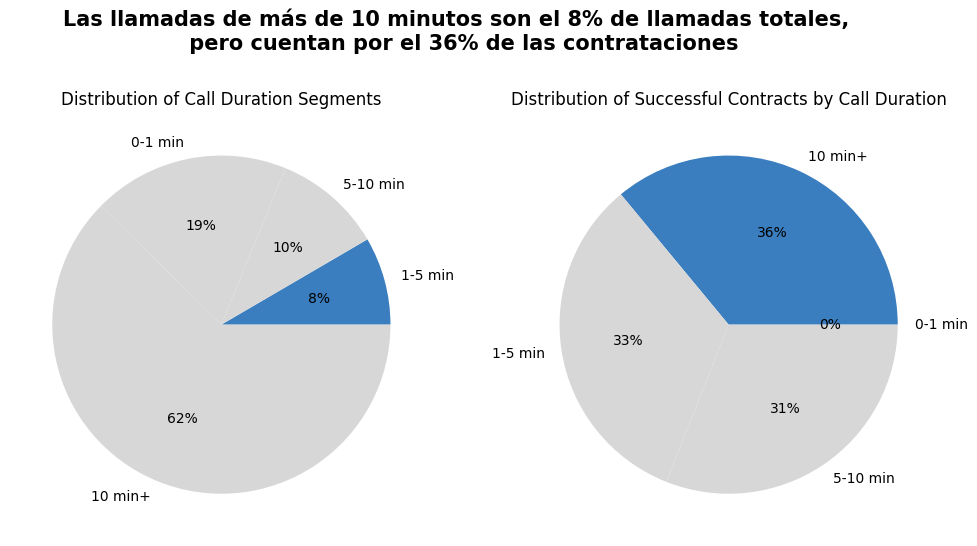

In [12]:
"""
15 min +             956
10 min - 15 min     2508
0-1 min             4282
5-10 min            7740
1-5 min            25698
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Count of call duration segments
labels1 = ['1-5 min','5-10 min','0-1 min','10 min+']
total1 = df.groupby('duration_segment', observed= True)['y'].count().sort_values(ascending= True)


ax1.pie(total1, labels= labels1, colors= ["#3a7ebf"]  + ['#d7d7d7'] * (len(labels1) - 1), autopct= '%1.0f%%')
ax1.set_title('Distribution of Call Duration Segments')

# Count of Successful Contracted
labels2 = ['10 min+','1-5 min','5-10 min','0-1 min']
total2 = df.query('y == "yes"')['duration_segment'].value_counts(normalize = True).round(2).sort_values(ascending= False)

ax2.pie(total2, labels = labels2, colors= ["#3a7ebf"] + ['#d7d7d7'] * (len(labels2) - 1),  autopct='%1.0f%%')
ax2.set_title('Distribution of Successful Contracts by Call Duration')

plt.suptitle('Las llamadas de más de 10 minutos son el 8% de llamadas totales, \n pero cuentan por el 36% de las contrataciones', fontsize=15, fontweight='bold', y=1.02)

plt.show()

# colors= ["#3a7ebf","#d7d7d7","#d7d7d7","#d7d7d7"]
# %1.1f%%'
# lambda p: f'{p:1.0f}%' if p > 0 else ''

### Duracion de las llamadas excluyendo los outliers

In [ ]:
# Quitamos los outliers
limite_inferior, limite_superior = limites_outliers(df,'duration')

Valor del segundo cuartil (25%): 102.00
Valor del tercer cuartil (75%): 319.00
Valor del rango intercuartil (IQR): 217.00
Los valores atípicos se definen como aquellos que caen fuera del siguiente rango:
	 - Límite inferior (considerado extremadamente bajo): -223.50
	 - Límite superior (considerado extremadamente alto): 644.50


In [14]:
df_sin_outliers = df[(df['duration'] >= limite_inferior) & (df['duration'] <= limite_superior)]

In [15]:
pd.crosstab(df_sin_outliers['job'] , df_sin_outliers['duration'])

duration,0,1,2,3,4,5,6,7,8,9,...,635,636,637,638,639,640,641,642,643,644
job,,,,,,,,,,,,,,,,,,,,,
admin.,1,0,0,1,5,7,11,17,16,22,...,3,2,1,5,4,0,4,2,6,2
blue-collar,2,1,0,1,3,8,4,12,16,17,...,3,2,3,1,0,2,2,2,2,2
entrepreneur,0,0,1,0,0,1,1,4,6,4,...,0,1,1,1,1,0,1,1,0,0
housemaid,0,0,0,0,0,0,0,1,1,5,...,0,0,1,1,0,0,0,0,0,0
management,1,0,0,0,1,1,0,2,8,2,...,0,2,2,3,0,2,1,0,0,1
retired,0,1,0,0,0,0,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0
self-employed,0,0,0,0,1,2,1,0,2,2,...,0,0,0,0,1,1,0,0,1,1
services,0,1,0,0,0,3,6,4,4,8,...,1,2,0,0,1,2,0,1,3,0
student,0,0,0,0,0,2,3,2,0,3,...,0,0,1,0,0,0,0,1,0,0


In [16]:
# EXTRA

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['0-25', '25-35', '35-45', '45-55', '55-65', '+65']

df_sin_outliers['intervalo_edad'] = pd.cut(
    df_sin_outliers['age'],
    bins=bins, 
    labels = labels,
    right = False,
    ordered=True
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18840\2589069433.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers['intervalo_edad'] = pd.cut(


In [ ]:
pd.crosstab(df_sin_outliers['intervalo_edad'] , df_sin_outliers['duration'])

duration,0,1,2,3,4,5,6,7,8,9,...,635,636,637,638,639,640,641,642,643,644
intervalo_edad,,,,,,,,,,,,,,,,,,,,,
0-25,0,0,0,0,0,1,1,3,2,4,...,0,0,1,1,0,1,0,1,0,0
25-35,1,0,0,1,6,15,22,18,22,27,...,0,3,4,4,2,2,6,2,10,2
35-45,1,2,0,1,3,6,8,17,25,18,...,7,3,2,8,3,4,2,4,3,4
45-55,1,0,1,1,2,5,4,11,16,21,...,2,4,4,0,4,0,1,3,2,2
55-65,1,0,0,0,1,3,2,5,4,7,...,1,0,0,1,0,2,1,0,0,2
+65,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


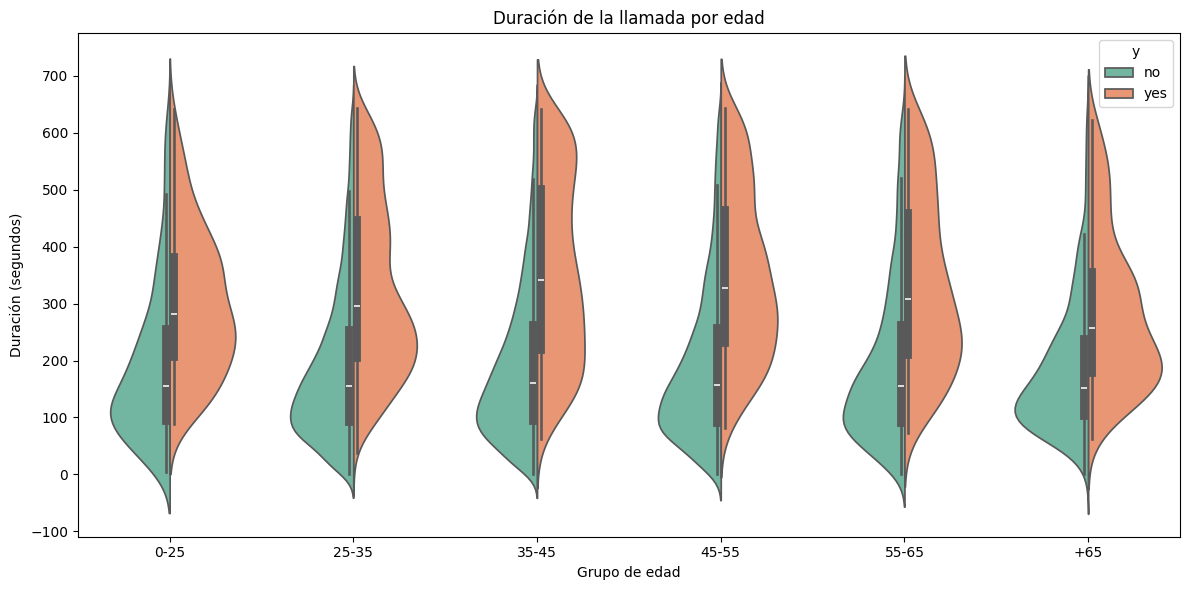

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=df_sin_outliers,
    x='intervalo_edad',
    y='duration',
    hue='y',
    split=True,
    palette='Set2',
    ax=ax
)

ax.set_title('Duración de la llamada por edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Duración (segundos)')

plt.tight_layout()
plt.show()

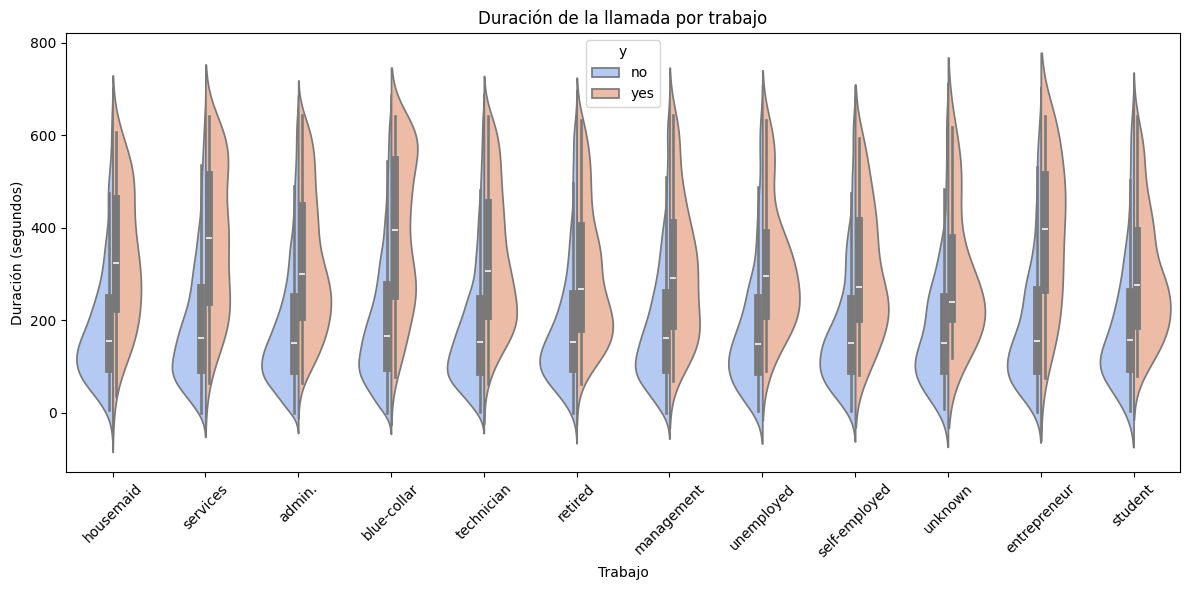

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=df_sin_outliers,
    x='job',
    y='duration',
    hue='y',
    split=True,
    palette='coolwarm',
    ax=ax
)

ax.set_title('Duración de la llamada por trabajo')
ax.set_xlabel('Trabajo')
ax.set_ylabel('Duración (segundos)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Analizamos la capacidad de conversión de las personas previamente contactadas

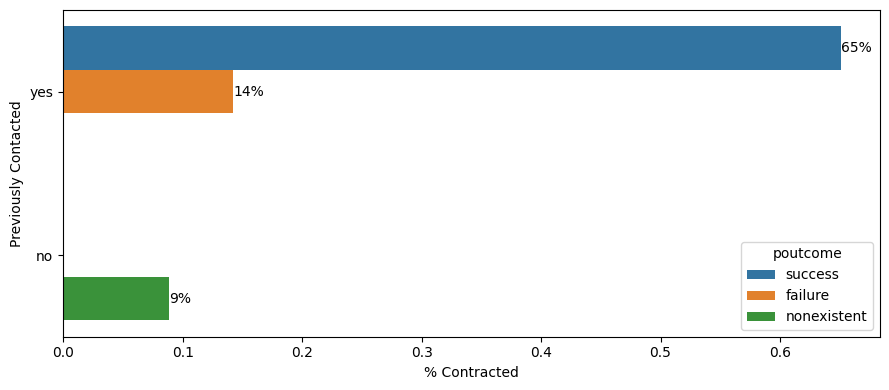

In [20]:
df['previously_attempted'] = df['previous'].apply(lambda x: 'yes' if x > 0 else 'no')

fig, ax = plt.subplots(figsize=(9, 4))

data = (
    df.groupby(['previously_attempted', 'poutcome'])['y']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
    .pivot(index=['previously_attempted', 'poutcome'], columns='y', values='proportion')
    .fillna(0)
    .sort_values(by='yes', ascending=False)
)

sns.barplot(
    data=data,
    x='yes',
    y='previously_attempted',
    hue='poutcome',
    ax=ax
)

ax.set_xlabel('% Contracted')
ax.set_ylabel('Previously Contacted')

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:.0%}', fontsize=10)

plt.tight_layout()
plt.show()

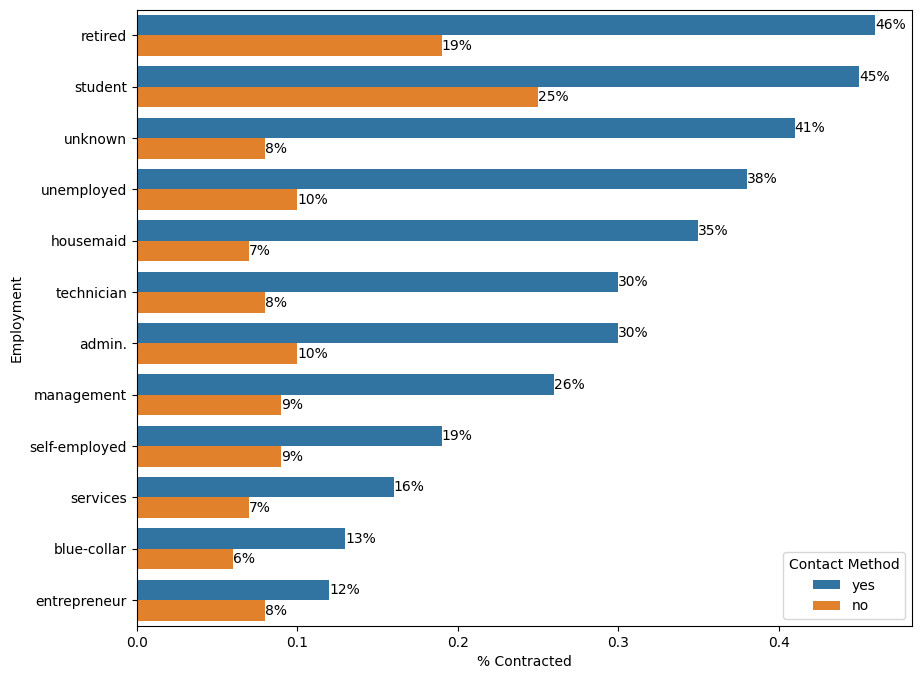

In [21]:
ax = plt.subplots(figsize=(10, 8))

ax = sns.barplot(
    df.groupby(['job','previously_attempted'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['job','previously_attempted'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job',
    hue = 'previously_attempted'
)

ax.set(xlabel='% Contracted', ylabel='Employment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.legend(title='Contact Method')


plt.show()

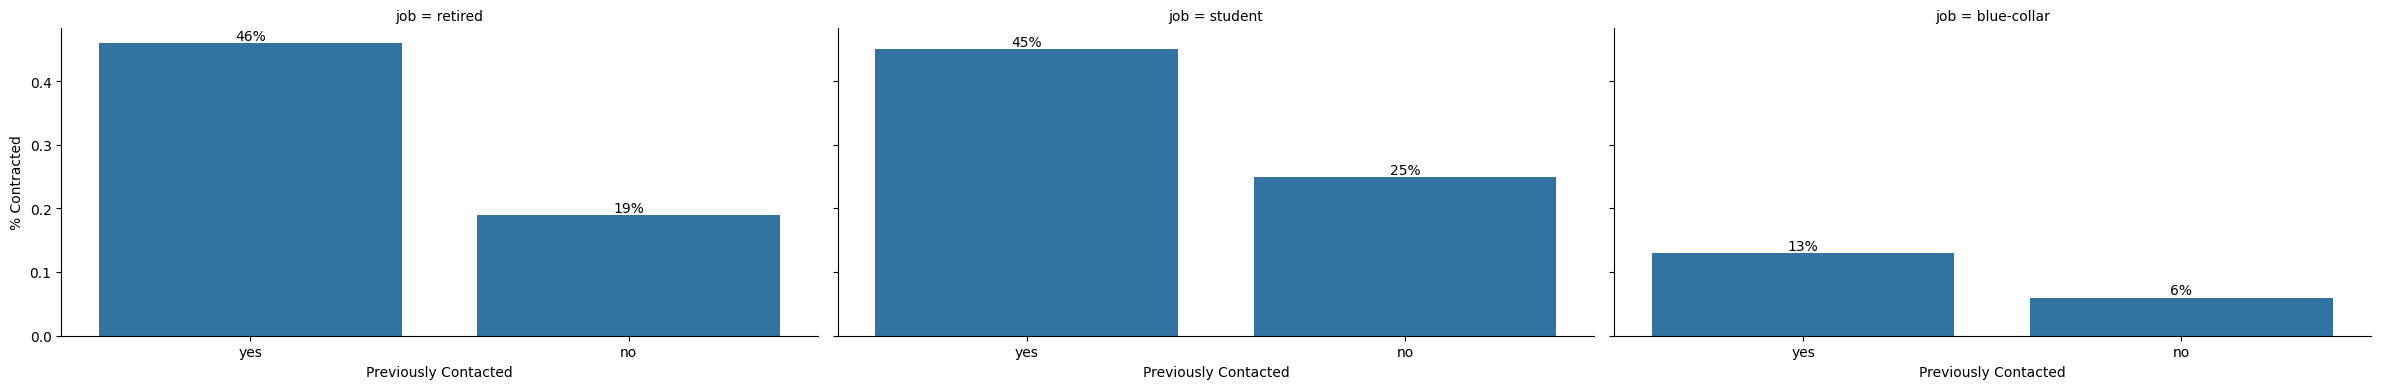

In [22]:
ax = sns.catplot(
    data= df.query('job == "student" | job == "retired" | job == "blue-collar"').groupby(['previously_attempted','job'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','job'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "previously_attempted", 
    y= "yes", 
    col= "job",
    kind="bar", height=4, aspect=2
)

for ax in ax.axes.flat:
    ax.set(ylabel='% Contracted', xlabel='Previously Contacted')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

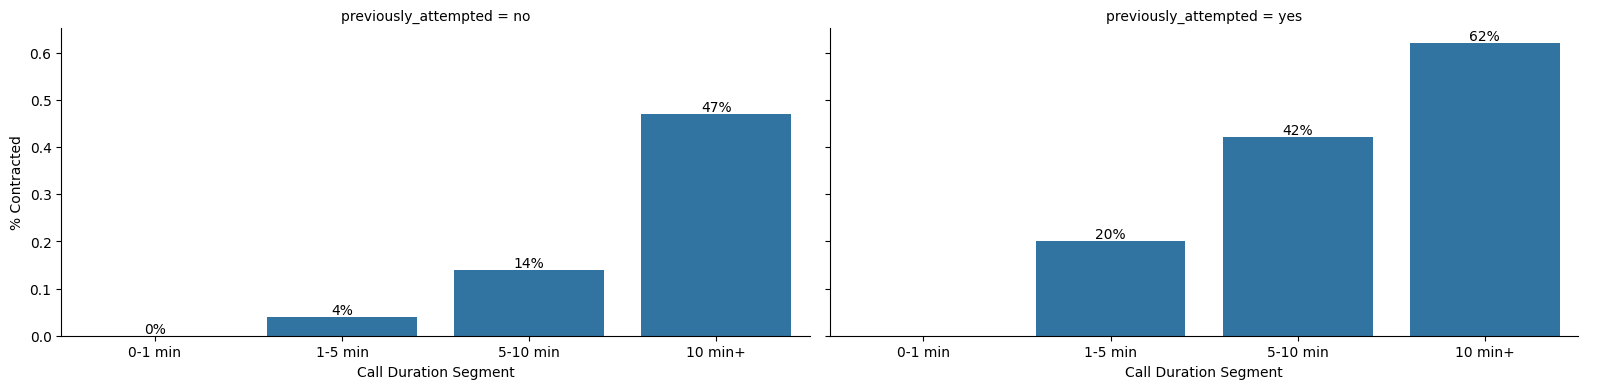

In [23]:
ax = sns.catplot(
    data= df.groupby(['previously_attempted','duration_segment'], observed= True)['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x= "duration_segment", 
    y= "proportion", 
    col= "previously_attempted",
    kind="bar", height=4, aspect=2
)

for ax in ax.axes.flat:
    ax.set(ylabel='% Contracted', xlabel='Call Duration Segment')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

In [24]:
(df.groupby(['previously_attempted','y'])['duration_minutes'].mean()).reset_index().pivot(index= 'previously_attempted', columns = 'y', values= 'duration_minutes').round(2)

y,no,yes
previously_attempted,,
no,3.69,10.39
yes,3.59,6.76


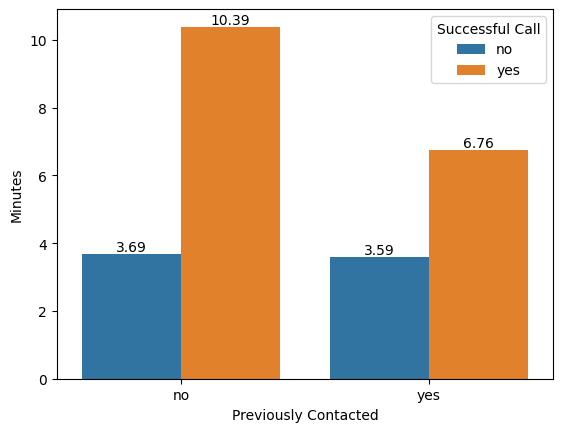

In [25]:
data = (df.groupby(['previously_attempted','y'])['duration_minutes'].mean()).reset_index().round(2)

ax = sns.barplot(
    data=data,
    x='previously_attempted',
    y='duration_minutes',
    hue='y'
)

ax.set(xlabel='Previously Contacted', ylabel='Minutes')
plt.legend(title='Successful Call')


for container in ax.containers:
    ax.bar_label(container, fontsize=10)

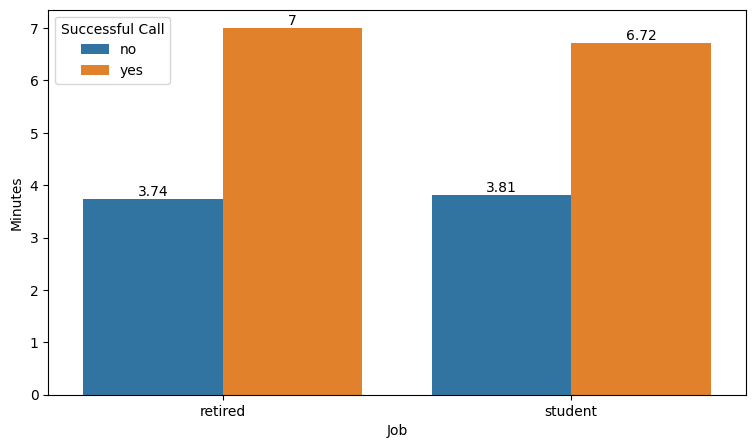

In [26]:
ax = plt.subplots(figsize=(9, 5))

data = (df.query('job == "student" | job == "retired"').groupby(['job','y'])['duration_minutes'].mean()).reset_index().round(2)

ax = sns.barplot(
    data=data,
    x='job',
    y='duration_minutes',
    hue='y'
)

ax.set(xlabel='Job', ylabel='Minutes')
plt.legend(title='Successful Call')


for container in ax.containers:
    ax.bar_label(container, fontsize=10)

### Conversión de la campaña por season, day of week, campaign y age

In [27]:
df['season'] = df['month'].apply(lambda x: seasons(x))

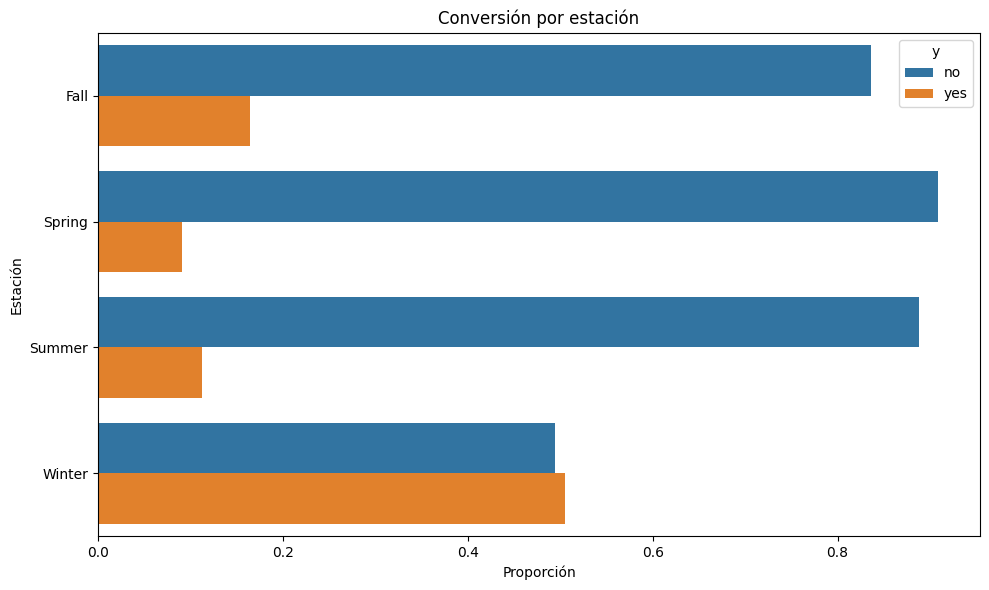

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

data = (
    df.groupby('season')['y']
    .value_counts(normalize=True)
    .reset_index()
)

sns.barplot(
    data=data,
    x='proportion',
    y='season',
    hue='y',
    ax=ax
)

ax.set_title('Conversión por estación')
ax.set_xlabel('Proporción')
ax.set_ylabel('Estación')

plt.tight_layout()
plt.show()

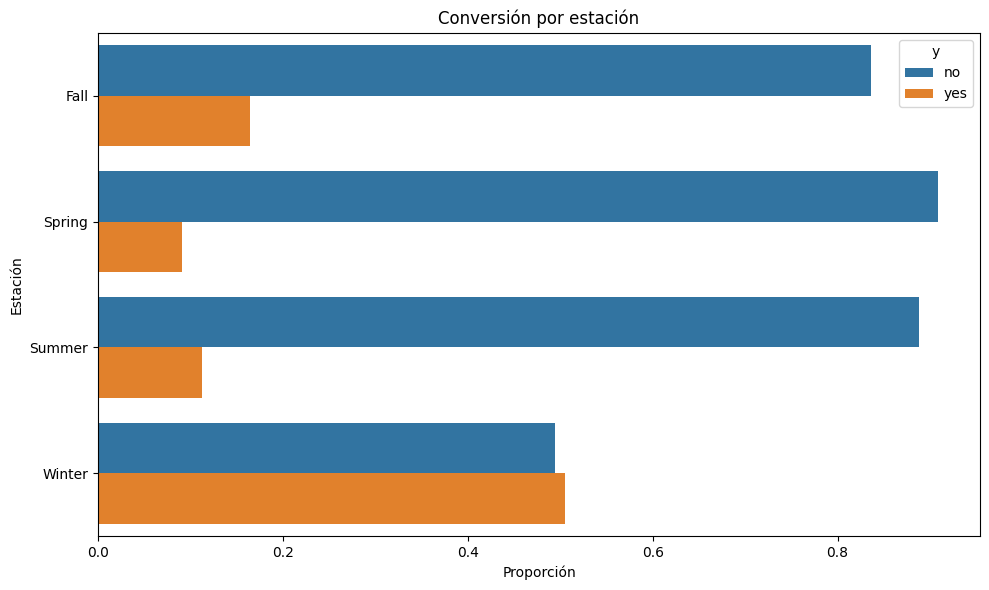

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

data = (
    df.groupby('season')['y']
    .value_counts(normalize=True)
    .reset_index()
)

sns.barplot(
    data=data,
    x='proportion',
    y='season',
    hue='y',
    ax=ax
)

ax.set_title('Conversión por estación')
ax.set_xlabel('Proporción')
ax.set_ylabel('Estación')

plt.tight_layout()
plt.show()

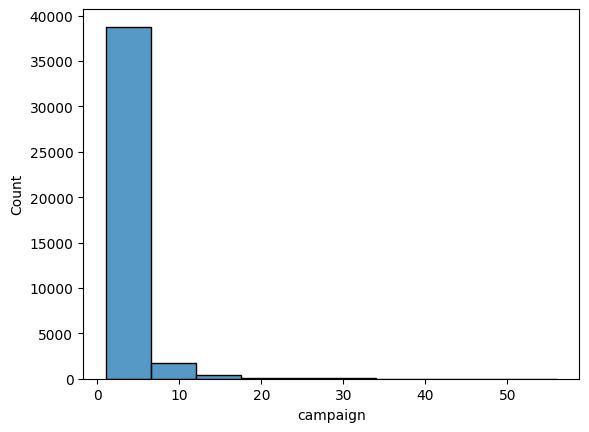

In [30]:
fig = sns.histplot(
    data=df, 
    x="campaign",
    bins = 10
    )

In [31]:
bins = [0,1,2,5,10,np.inf]
names = ['0 times', '1x', '2-5x', '5-10x','10x +']

df['campaign_segment'] = pd.cut(df['campaign'], bins, labels=names)

C:\Users\migue\AppData\Local\Temp\ipykernel_18840\3489383404.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['campaign_segment', 'previously_attempted'])['y']


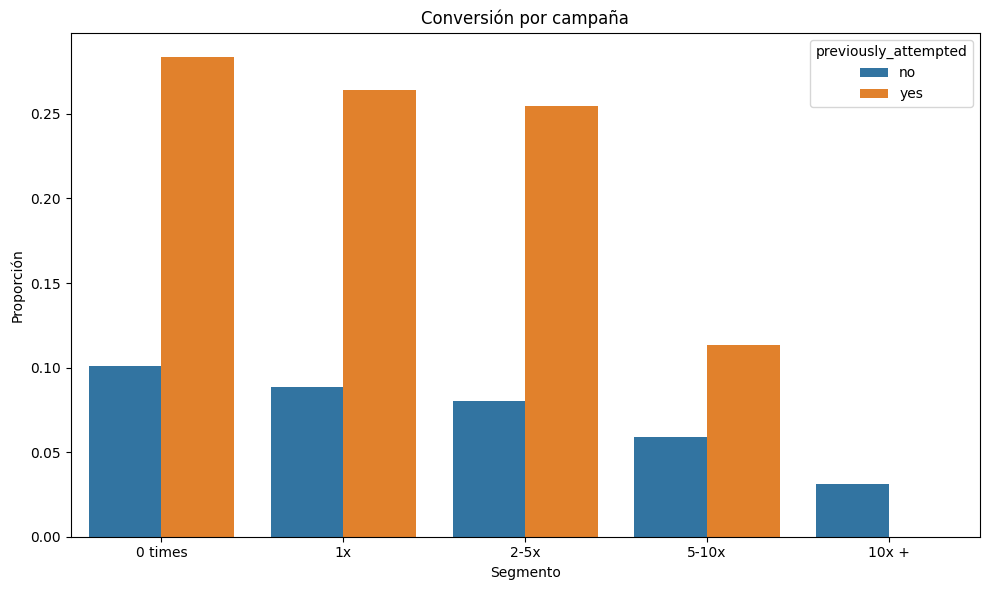

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

data = (
    df.groupby(['campaign_segment', 'previously_attempted'])['y']
    .value_counts(normalize=True)
    .reset_index()
)

data = data[data['y'] == 'yes']

sns.barplot(
    data=data,
    x='campaign_segment',
    y='proportion',
    hue='previously_attempted',
    ax=ax
)

ax.set_title('Conversión por campaña')
ax.set_xlabel('Segmento')
ax.set_ylabel('Proporción')

plt.tight_layout()
plt.show()

#### Exito de conversión por rango de edad

Dividimos edades en rangos para ver categoricamente. Los "bins" son inclusivos al valor máximo especificado en pd.cut (right = True)

In [33]:
bins = [0,25, 35, 45, 55, 65, np.inf]
names = ['<25', '26-35', '36-45', '46-55','56-65','66+']

df['age_segment'] = pd.cut(df['age'], bins, labels=names, right= True)

##

C:\Users\migue\AppData\Local\Temp\ipykernel_18840\3242220291.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_segment', 'previously_attempted'])['y']


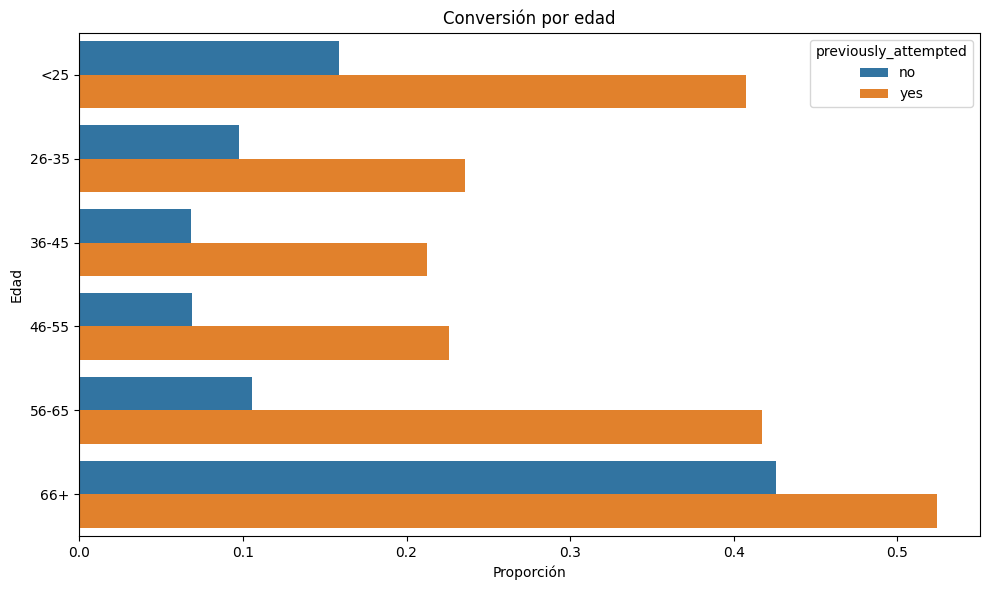

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

data = (
    df.groupby(['age_segment', 'previously_attempted'])['y']
    .value_counts(normalize=True)
    .reset_index()
)

data = data[data['y'] == 'yes']

sns.barplot(
    data=data,
    x='proportion',
    y='age_segment',
    hue='previously_attempted',
    ax=ax
)

ax.set_title('Conversión por edad')
ax.set_xlabel('Proporción')
ax.set_ylabel('Edad')

plt.tight_layout()
plt.show()

### Heatmap

C:\Users\migue\AppData\Local\Temp\ipykernel_18840\3767502667.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sin_outliers.groupby(['intervalo_edad', 'job'])['y']


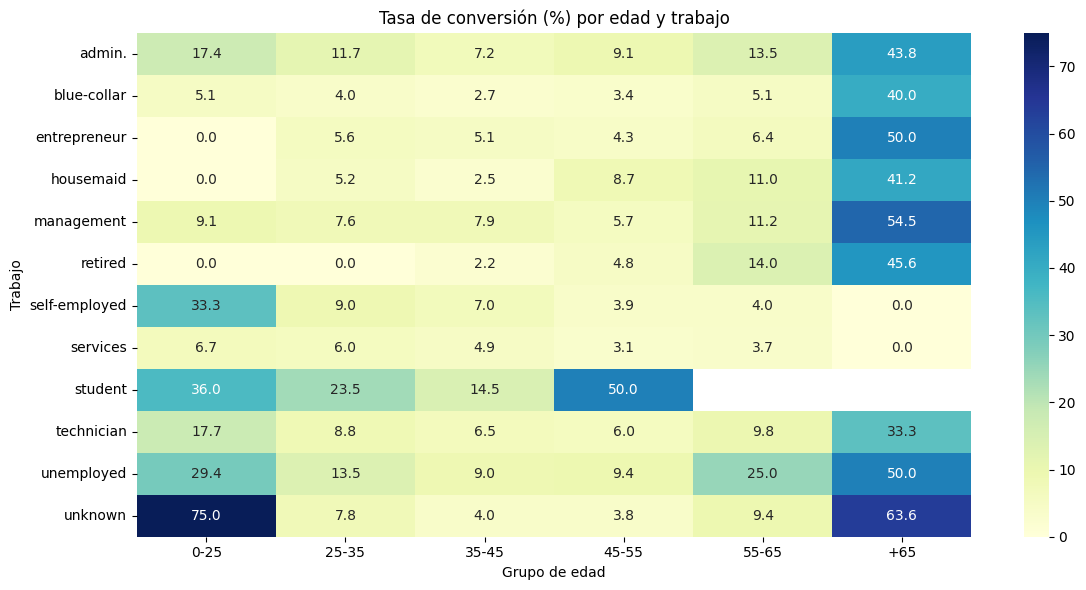

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

df_age_job = (
    df_sin_outliers.groupby(['intervalo_edad', 'job'])['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .reset_index()
)

tabla = df_age_job.pivot(index='job', columns='intervalo_edad', values='y')

sns.heatmap(tabla, annot=True, fmt=".1f", cmap='YlGnBu', ax=ax)

ax.set_title('Tasa de conversión (%) por edad y trabajo')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Trabajo')

plt.tight_layout()
plt.show()

[⬆ Volver al índice](#indice)

<a id="conclusiones"></a>
## Conclusiones Extra 📝

En esta sección se resumen los principales hallazgos del análisis de las campañas de marketing del banco.

[⬆ Volver al índice](#indice)